In [1]:
from src.Elements import Elements
from torchview import draw_graph
import graphviz 
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models import VisionTransformer, VisionTransformerCNN, LT_VisionTransformer, XRFClassifier, ResNet1D, select_model

device = "cuda" if torch.cuda.is_available() else "cpu"



# model = select_model("LT_VisionTransformer", device=device)
# model = select_model("LT_VisionTransformer", device=device)
model = select_model("VisionTransformerCNN", device=device, num_classes= 17)
# model = select_model("XRFNet4096", device=device, num_outputs=17)
# model = select_model("XRFClassifier", device=device, num_outputs=17)
# model = select_model("VisionTransformer", device=device, num_classes = 17)
# model = select_model("LT_VisionTransformer", device=device, num_classes= 17)
# model = select_model("ResNet1D", device=device, num_outputs= 17)

model.to(device)

print(model)

print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

VisionTransformerCNN(
  (cnn): Sequential(
    (0): LazyConv1d(0, 32, kernel_size=(8,), stride=(4,), padding=(2,))
    (1): ReLU()
    (2): LazyConv1d(0, 64, kernel_size=(8,), stride=(4,), padding=(2,))
    (3): ReLU()
    (4): LazyConv1d(0, 64, kernel_size=(1,), stride=(1,))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): TransformerMLP(
        (feedforward): Sequential(
          (0): LazyLinear(in_features=0, out_features=1024, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): LazyLinear(in_features=0, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
       

In [3]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X_regression_20250504_221340.npy")
y = np.load("data/training_data/artificial/y_regression_20250504_221348.npy")
y /= 4096
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 160)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 160)


(4096,) (17,)
[0. 0. 0. ... 0. 0. 0.] [0.         0.04524926 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.00721806 0.         0.         0.02817667 0.16838942]


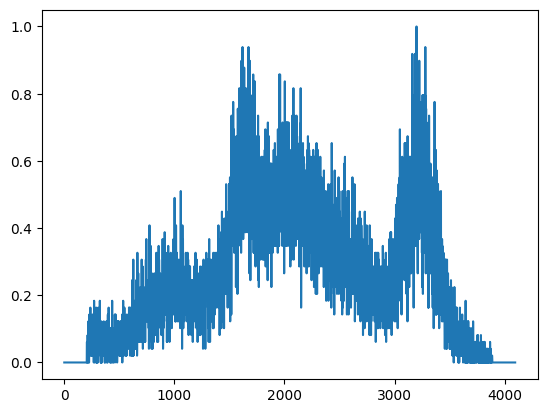

In [4]:
import matplotlib.pyplot as plt
print(X[0].shape, y[0].shape)
print(X[0], y[0])
plt.plot(X[0])

In [5]:
from pathlib import Path
from datetime import datetime 

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.MSELoss()
results = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=50, mode="regression", patience=5)


2025-05-06 19:52:34,848 - INFO - Starting training process (mode: regression, epochs: 50, patience: 5)
2025-05-06 19:52:34,850 - INFO - --- Epoch 1/50 ---
2025-05-06 19:52:35,780 - INFO -   Batch 10/1407, Loss: 0.0114755
2025-05-06 19:52:36,522 - INFO -   Batch 20/1407, Loss: 0.0079230
2025-05-06 19:52:37,275 - INFO -   Batch 30/1407, Loss: 0.0051796
2025-05-06 19:52:38,017 - INFO -   Batch 40/1407, Loss: 0.0038686
2025-05-06 19:52:38,763 - INFO -   Batch 50/1407, Loss: 0.0037215
2025-05-06 19:52:39,507 - INFO -   Batch 60/1407, Loss: 0.0034316
2025-05-06 19:52:40,242 - INFO -   Batch 70/1407, Loss: 0.0033726
2025-05-06 19:52:41,066 - INFO -   Batch 80/1407, Loss: 0.0034574
2025-05-06 19:52:41,839 - INFO -   Batch 90/1407, Loss: 0.0030266
2025-05-06 19:52:42,607 - INFO -   Batch 100/1407, Loss: 0.0030269
2025-05-06 19:52:43,371 - INFO -   Batch 110/1407, Loss: 0.0029896
2025-05-06 19:52:44,132 - INFO -   Batch 120/1407, Loss: 0.0026663
2025-05-06 19:52:44,900 - INFO -   Batch 130/1407,

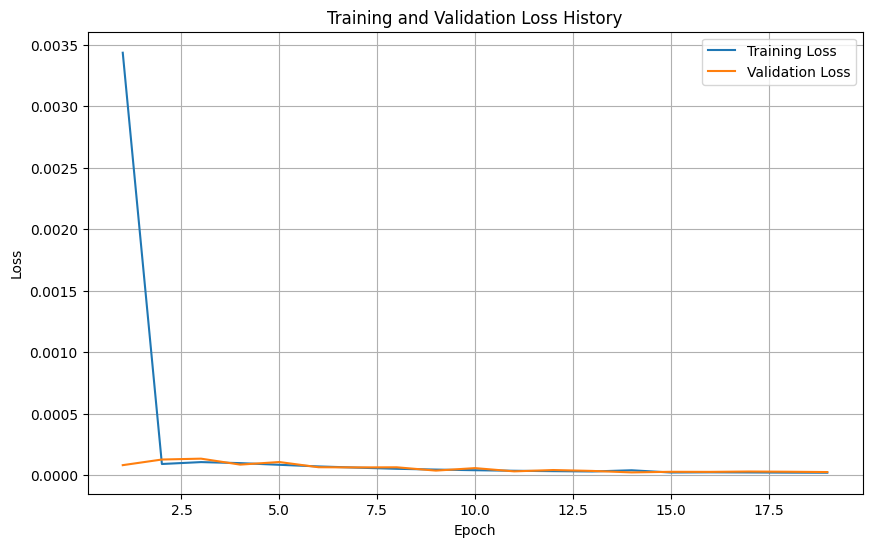

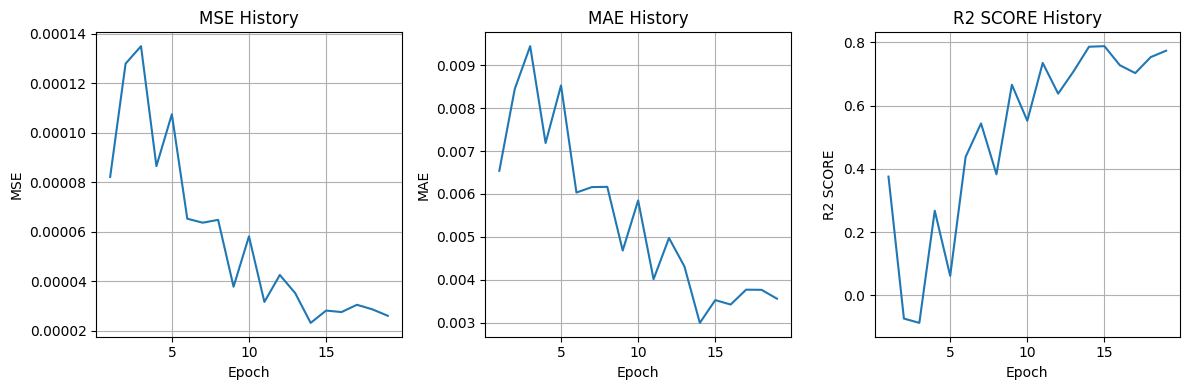

In [6]:
def plot_metrics(results, mode="supervised"):
    """
    Plots the training and validation loss history and evaluation metrics history.

    Args:
        results (dict): The dictionary returned by the train function.
        mode (str): The training mode used ("supervised", "autoencoder", "constrained_autoencoder", "regression").
    """
    train_loss_history = results.get('train_loss_history', [])
    valid_loss_history = results.get('valid_loss_history', [])
    metric_histories = results.get('metric_histories', {})

    epochs = range(1, len(train_loss_history) + 1)

    # Plot Loss History
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss_history, label='Training Loss')
    plt.plot(epochs, valid_loss_history, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Metric Histories based on mode
    if mode in ["supervised", "constrained_autoencoder"]:
        plt.figure(figsize=(12, 8))
        num_metrics = len(metric_histories)
        # Determine grid size for subplots
        n_cols = 2
        n_rows = (num_metrics + n_cols - 1) // n_cols

        for i, (metric_name, history) in enumerate(metric_histories.items()):
            plt.subplot(n_rows, n_cols, i + 1)
            plt.plot(epochs, history)
            plt.xlabel('Epoch')
            plt.ylabel(metric_name.replace('_', ' ').title()) # Format metric name nicely
            plt.title(f'{metric_name.replace("_", " ").title()} History')
            plt.grid(True)

        plt.tight_layout()
        plt.show()

    elif mode == "regression":
        plt.figure(figsize=(12, 4))
        num_metrics = len(metric_histories)
        # Determine grid size for subplots
        n_cols = 3 # MSE, MAE, R2
        n_rows = (num_metrics + n_cols - 1) // n_cols # Should be 1 row

        for i, (metric_name, history) in enumerate(metric_histories.items()):
            plt.subplot(n_rows, n_cols, i + 1)
            plt.plot(epochs, history)
            plt.xlabel('Epoch')
            plt.ylabel(metric_name.upper().replace('_', ' ')) # Keep regression metrics uppercase
            plt.title(f'{metric_name.upper().replace("_", " ")} History')
            plt.grid(True)

        plt.tight_layout()
        plt.show()

    elif mode == "autoencoder":
        print.info("No additional metrics to plot for autoencoder mode beyond loss.")


plot_metrics(results, mode="regression")

In [7]:
MODEL_NAME = model.__class__.__name__
torch.save(model.state_dict(), Path(f"data/model_weights/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}"))